
### What is Batch Normalization?

Imagine you are baking cookies, and you want all the cookies to be about the same size and shape. But sometimes, the dough is too sticky or too dry, and the cookies turn out very different. Batch Norm is like a tool that helps make the dough consistent before baking, so all cookies come out nice and similar!

In deep learning, when a computer learns from data, the inputs to each layer (like ingredients for the cookies) can be very different or "unbalanced," making it harder for the model to learn well. Batch Norm "normalizes" these inputs, adjusting them to be more balanced and consistent across a batch (a group) of examples.

***

### Why do we need Batch Norm?

- It keeps the data going into each layer steady, so the computer doesn’t get confused.
- Helps the model learn faster.
- Helps the model get better accuracy and not get stuck.

***

### How does Batch Norm work? (Math Part)

1. **Take a batch of inputs:** Suppose we have a batch (group) of 4 numbers going into a layer:  
   $$ x = [2, 4, 6,*Calculate the mean (average):**  
   $$ \mu = \frac{2 + 4 + 6 + 8}{4} = \frac{20}{4} = 5 $$

3. **Calculate the variance (how spread out the numbers are):**  
   $$
   \sigma^2 = \frac{(2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2}{4} = \frac{9 + 1 + 1 + 9}{4} = \frac{20}{4} = 5
   $$

4. **Normalize the values:** Subtract the mean and divide by the square root of variance (plus a small number to avoid division by zero, say 0.001):  
   $$
   \hat{x_i} = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} = \frac{x_i - 5}{\sqrt{5 + 0.001}}
   $$
   
   For example, for $$ x_1 = 2 $$:  
   $$
   \hat{x_1} = \frac{2-5}{\sqrt{5.001}} = \frac{-3}{2.236} \approx -1.34
   $$

   Do this for all values.

5. **Scale and shift:** Sometimes, we want to allow the network to adjust these normalized values a bit, so we multiply by a scale factor $$ \gamma $$ and add a shift factor $$ \beta $$. Initially, these can be 1 and 0, meaning no change, but the network learns these values:  
   $$
   y_i = \gamma \hat{x_i} + \beta
   $$

***

### Simple analogy

Think of Batch Norm like this:

- You have a class of kids running a race.
- Some kids run very fast, some very slow.
- Before the race starts each day, we ask all kids to line up in order with the average pace (mean) and try to keep everyone’s pace close together (reduce variance).
- Then we let each kid adjust their speed a bit (scale and shift) as they feel comfortable.
- This way, the race is fairer and easier to improve your speed day by day.

***

### Summary

- Batch Norm normalizes inputs so they have a mean close to 0 and variance close to 1.
- This helps the neural network learn better and faster.
- It adjusts data in small batches during training.
- The math involves calculating mean, variance, normalizing, then scaling and shifting.



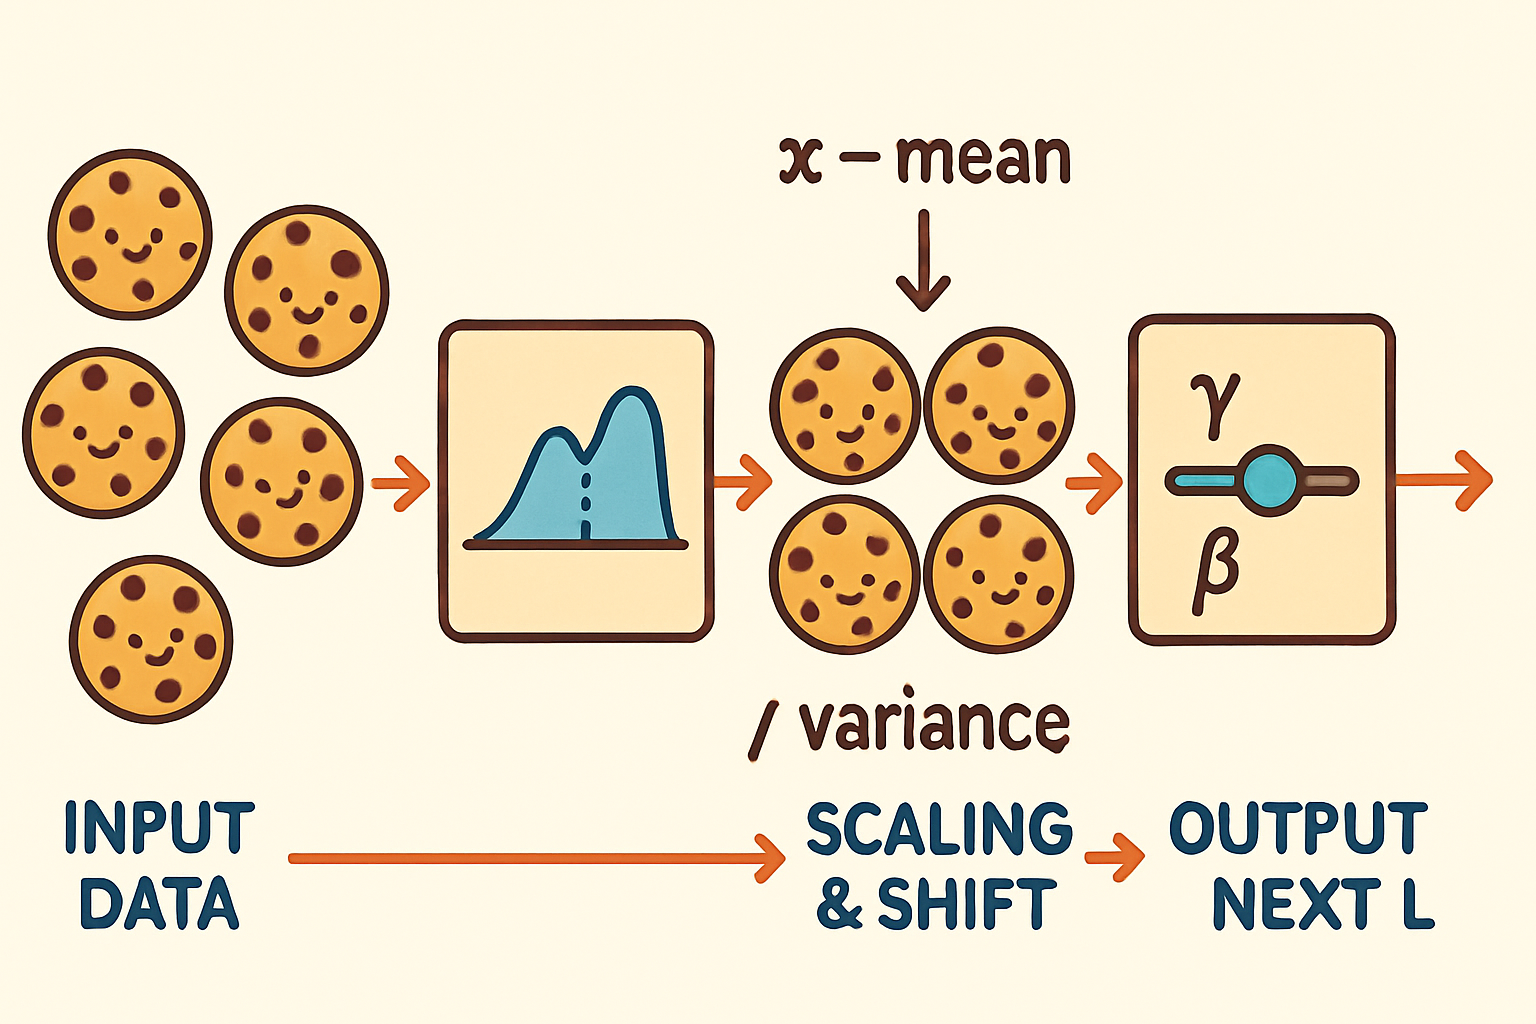

Batch Normalization (Batch Norm) works by normalizing the inputs of a layer within a mini-batch using numbers and adjustable parameters during training to help neural networks learn better. Here's a detailed depiction with numbers, explanation of parameters, how they help, pros and cons, and alternatives.

### Depiction with Numbers

Suppose you have a batch of 4 inputs going into a layer:

- Inputs: $$ x = [2, 4, 6, 1: Calculate the mean (average):

$$
\mu = \frac{2 + 4 + 6 + 8}{4} = 5
$$

Step 2: Calculate variance (spread of data):

$$
\sigma^2 = \frac{(2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2}{4} = 5
$$

Step 3: Normalize each input to have mean 0 and variance 1:

$$
\hat{x_i} = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} = \frac{x_i - 5}{\sqrt{5 + 0.001}}
$$

For $$ x_1 = 2 $$:

$$
\hat{x_1} = \frac{2-5}{2.236} \approx -1.34
$$

Do this for all inputs.

Step 4: Scale and shift each normalized input with learnable parameters $$\gamma$$ and $$\beta$$:

$$
y_i = \gamma \hat{x_i} + \beta
$$

- $$\gamma$$ (scale) and $$\beta$$ (shift) are **learnable parameters** adjusted during training to allow the network flexibility.

For example, if $$\gamma=2$$ and $$\beta=1$$, then:

$$
y_1 = 2 \times (-1.34) + 1 = -1.68
$$

### Parameters in Training

- **$$\gamma$$ (scale)**: Multiplicative factor, learned by the model to scale normalized input.
- **$$\beta$$ (shift)**: Additive factor, learned by the model to shift normalized input.

These parameters are **learnable**, meaning the model updates them during training to optimize learning.

Mean ($$\mu$$) and variance ($$\sigma^2$$) are calculated from batch data during training but are **not learnable parameters**. During inference, running averages of these values are used.

### How Batch Norm Helps

- **Stabilizes learning** by keeping layer inputs normalized.
- **Faster training** as gradients flow better.
- **Allows higher learning rates** without divergence.
- **Regularizes the model** slightly, reducing need for dropout.
- Helps reduce **internal covariate shift** (changes in layer input distributions).

### Pros of Batch Normalization

- Speeds up training convergence.
- Improves model accuracy.
- Allows use of higher learning rates.
- Acts as a form of regularization, reducing overfitting.

### Cons of Batch Normalization

- Depends on batch size; small batches can give noisy estimates.
- Adds computational overhead.
- During inference, requires maintaining running statistics.
- Not ideal for recurrent neural networks or small batch scenarios.

### Alternatives to Batch Normalization

- **Layer Normalization:** Normalizes across features per sample, useful in RNNs.
- **Instance Normalization:** Normalizes each sample independently, used in style transfer.
- **Group Normalization:** Divides channels into groups and normalizes, good for small batch sizes.
- **Weight Normalization:** Normalizes weights instead of activations.

Batch Norm is widely popular but depending on the task and architecture, one alternative might be more suitable.

***



In [1]:
import torch
import torch.nn as nn

class SimpleNet(nn.Module):
  def __init__(self):
    super(SimpleNet,self).__init__()
    self.linear = nn.Linear(4,4)

    self.batch_norm = nn.BatchNorm1d(4)

  def forward(self,x):
    x = self.linear(x)
    x = self.batch_norm(x)
    return x

x = torch.tensor([[2.0, 4.0, 6.0, 8.0],
                  [1.0, 3.0, 5.0, 7.0],
                  [0.0, 2.0, 4.0, 6.0]])

net = SimpleNet()
net.train()

output = net(x)
print("Output after batch norm")
print(output)

Output after batch norm
tensor([[-1.2246e+00, -1.2247e+00,  1.2247e+00,  1.2247e+00],
        [ 4.4402e-07, -1.0611e-08, -1.2719e-07, -3.0394e-07],
        [ 1.2246e+00,  1.2247e+00, -1.2247e+00, -1.2247e+00]],
       grad_fn=<NativeBatchNormBackward0>)
